In [6]:
# Core dependencies
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import emoji
from datetime import datetime
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# File paths
INPUT_CHAT_FILE = "chat.txt"
RAW_CSV_OUTPUT = "whatsapp_chat.csv"
CLEANED_CSV_OUTPUT = "cleaned_chat.csv"
SENTIMENT_CSV_OUTPUT = "sentiment_chat.csv"
PERSONALITY_CSV_OUTPUT = "personality_chat.csv"
TOPIC_CSV_OUTPUT = "topic_chat.csv"

# Analysis parameters
POSITIVE_THRESHOLD = 0.05
NEGATIVE_THRESHOLD = -0.05
NUM_TOPICS = 5
TOP_N_WORDS = 15
MIN_MESSAGE_LENGTH = 3
SAMPLE_SIZE = 5000

# Visualization settings
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
sns.set_palette('viridis')

COLOR_PALETTE = {
    'positive': '#4CAF50',
    'negative': '#F44336',
    'neutral': '#9E9E9E',
    'highlight': '#2196F3',
    'person1': '#FF9F43',
    'person2': '#26C6DA',
    'system': '#9575CD'
}

# Initialize progress bar
tqdm.pandas()

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [7]:
pip install emoji

In [8]:
def load_and_parse_chat(file_path):
    """Parse WhatsApp chat file into structured DataFrame"""
    pattern = re.compile(
        r'^(\d{1,2}/\d{1,2}/\d{2,4}),? (\d{1,2}:\d{2}(?:\s?[APap][mM])?) - '
        r'([^:]+): (.+)|^(\d{1,2}/\d{1,2}/\d{2,4}),? (\d{1,2}:\d{2}(?:\s?[APap][mM])?) - (.+)'
    )

    data = []
    current_entry = None

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in tqdm(file, desc="Parsing chat"):
            line = line.strip()
            if not line:
                continue

            match = pattern.match(line)
            if match:
                if current_entry:
                    data.append(current_entry)

                if match.group(1):  # Standard message
                    date, time, name, text = match.group(1, 2, 3, 4)
                else:  # System message
                    date, time, text = match.group(5, 6, 7)
                    name = "System"

                current_entry = {
                    'Date': date,
                    'Time': time,
                    'Name': name,
                    'Text': text,
                    'IsMedia': '<Media omitted>' in text
                }
            elif current_entry:
                current_entry['Text'] += '\n' + line

    if current_entry:
        data.append(current_entry)

    df = pd.DataFrame(data)
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Datetime'])
    df['DayOfWeek'] = df['Datetime'].dt.day_name()
    df['Hour'] = df['Datetime'].dt.hour

    return df

In [9]:
def clean_text(text, keep_emojis=True):
    """Comprehensive text cleaning pipeline"""
    if not isinstance(text, str) or not text.strip():
        return ""

    if keep_emojis:
        text = emoji.demojize(text, delimiters=(" ", " "))

    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<media omitted>", " ", text)
    text = re.sub(r"[^\w\s.,!?']", " ", text)

    tokens = word_tokenize(text)
    custom_stopwords = set(stopwords.words('english')) | {
        'whatsapp', 'media', 'omitted', 'message', 'deleted'
    }

    lemmatizer = WordNetLemmatizer()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in custom_stopwords and len(token) > 2
    ]

    return " ".join(tokens)

In [10]:
def analyze_sentiment(text):
    """Comprehensive sentiment analysis combining multiple approaches"""
    try:
        if not isinstance(text, str) or not text.strip():
            return pd.Series([0, 0, 0, 0, "Neutral", 0])

        # VADER analysis
        vader_scores = analyzer.polarity_scores(text)

        # TextBlob analysis
        blob = TextBlob(text)

        # Emoji analysis
        emoji_sent = get_emoji_sentiment(text)

        # Combined score
        combined = (
            vader_scores['compound'] * 0.6 +
            blob.sentiment.polarity * 0.3 +
            emoji_sent * 0.1
        )

        # Classification
        if combined >= POSITIVE_THRESHOLD:
            label = "Positive"
        elif combined <= NEGATIVE_THRESHOLD:
            label = "Negative"
        else:
            label = "Neutral"

        return pd.Series([
            vader_scores['compound'],
            blob.sentiment.polarity,
            blob.sentiment.subjectivity,
            combined,
            label,
            emoji_sent
        ])

    except Exception as e:
        print(f"Error analyzing sentiment: {str(e)}")
        return pd.Series([0, 0, 0, 0, "Neutral", 0])

In [11]:
def perform_topic_modeling(docs, num_topics=NUM_TOPICS):
    """Perform BERTopic modeling with custom settings"""
    try:
        vectorizer_model = CountVectorizer(
            stop_words='english',
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.8
        )

        topic_model = BERTopic(
            vectorizer_model=vectorizer_model,
            nr_topics=num_topics,
            language='english',
            calculate_probabilities=True,
            verbose=True
        )

        topics, probs = topic_model.fit_transform(docs)
        topic_info = topic_model.get_topic_info()
        topics = topic_model.reduce_outliers(docs, topics)

        return topic_model, topics, topic_info

    except Exception as e:
        print(f"Error in topic modeling: {str(e)}")
        return None, None, None

In [12]:
def analyze_personality_texts(texts, traits=None):
    """Analyze texts for personality traits using Empath"""
    try:
        lexicon = Empath()

        if traits is None:
            traits = [
                'positive_emotion', 'negative_emotion',
                'anger', 'sadness', 'joy', 'love',
                'social', 'family', 'friend'
            ]

        results = []

        for text in tqdm(texts, desc="Analyzing personality"):
            try:
                if not isinstance(text, str) or not text.strip():
                    results.append({trait: 0 for trait in traits})
                    continue

                analysis = lexicon.analyze(text, normalize=True)
                results.append({trait: analysis.get(trait, 0) for trait in traits})
            except Exception as e:
                print(f"Error analyzing text: {str(e)}")
                results.append({trait: 0 for trait in traits})

        return pd.DataFrame(results)

    except Exception as e:
        print(f"Error in personality analysis: {str(e)}")
        return pd.DataFrame()

In [13]:
def plot_sentiment_distribution(df):
    """Visualize sentiment distribution with percentages"""
    if 'Sentiment_Label' not in df.columns:
        print("Sentiment data not available.")
        return

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(
        x='Sentiment_Label',
        data=df,
        order=['Positive', 'Neutral', 'Negative'],
        palette=[COLOR_PALETTE['positive'], COLOR_PALETTE['neutral'], COLOR_PALETTE['negative']]
    )

    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height()/total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height() + 0.02 * total
        ax.annotate(percentage, (x, y), ha='center')

    plt.tight_layout()
    plt.show()

In [14]:
pip install bertopic

In [15]:
pip install empath

In [16]:
# Additional NLP dependencies
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

# Topic modeling
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Personality analysis
from empath import Empath

# Download NLTK resources
nltk.download(['punkt', 'stopwords', 'wordnet', 'vader_lexicon'])

# Initialize sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [17]:
def get_emoji_sentiment(text):
    """Calculate sentiment score based on emojis"""
    emoji_scores = {
        'positive': [':grinning:', ':smiley:', ':smile:', ':grin:', ':laughing:', ':sweat_smile:',
                    ':joy:', ':slightly_smiling_face:', ':wink:', ':blush:', ':yum:', ':relieved:',
                    ':heart_eyes:', ':kissing_heart:', ':kissing:', ':kissing_smiling_eyes:',
                    ':kissing_closed_eyes:', ':stuck_out_tongue_winking_eye:', ':stuck_out_tongue_closed_eyes:',
                    ':stuck_out_tongue:', ':money_mouth_face:', ':hugging_face:', ':smiling_face_with_three_hearts:'],
        'negative': [':angry:', ':rage:', ':pouting_face:', ':cry:', ':persevere:', ':triumph:',
                    ':disappointed:', ':worried:', ':confused:', ':slightly_frowning_face:',
                    ':frowning_face:', ':anguished:', ':fearful:', ':weary:', ':exploding_head:',
                    ':grimacing:', ':cold_sweat:', ':scream:', ':flushed:', ':zany_face:', ':face_with_raised_eyebrow:']
    }

    if not isinstance(text, str):
        return 0

    positive_count = sum(text.count(emoji) for emoji in emoji_scores['positive'])
    negative_count = sum(text.count(emoji) for emoji in emoji_scores['negative'])

    total = positive_count + negative_count
    if total == 0:
        return 0

    return (positive_count - negative_count) / total

In [18]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
# Load and parse the chat file
print("Loading and parsing chat file...")
chat_df = load_and_parse_chat(INPUT_CHAT_FILE)

# Save raw data
chat_df.to_csv(RAW_CSV_OUTPUT, index=False)
print(f"Raw data saved to {RAW_CSV_OUTPUT}")

# Clean the text data
print("Cleaning text data...")
chat_df['Cleaned_Text'] = chat_df['Text'].progress_apply(lambda x: clean_text(x, keep_emojis=True))

# Filter out short messages and media
chat_df = chat_df[chat_df['Cleaned_Text'].str.len() >= MIN_MESSAGE_LENGTH]
chat_df = chat_df[~chat_df['IsMedia']]

# Save cleaned data
chat_df.to_csv(CLEANED_CSV_OUTPUT, index=False)
print(f"Cleaned data saved to {CLEANED_CSV_OUTPUT}")

Loading and parsing chat file...


Parsing chat: 55432it [00:00, 123862.87it/s]


Raw data saved to whatsapp_chat.csv
Cleaning text data...


100%|██████████| 55218/55218 [00:24<00:00, 2270.28it/s]


Cleaned data saved to cleaned_chat.csv


Performing sentiment analysis...


100%|██████████| 49234/49234 [00:30<00:00, 1611.79it/s]


Sentiment data saved to sentiment_chat.csv


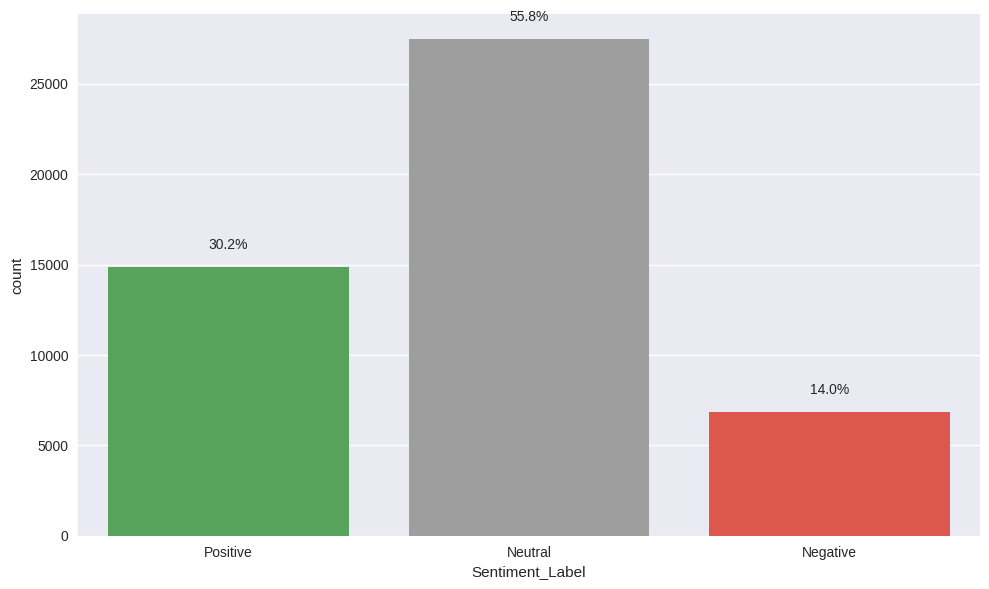

In [21]:
# Perform sentiment analysis
print("Performing sentiment analysis...")
sentiment_cols = ['Vader_Score', 'TextBlob_Polarity', 'TextBlob_Subjectivity',
                 'Combined_Score', 'Sentiment_Label', 'Emoji_Score']
chat_df[sentiment_cols] = chat_df['Cleaned_Text'].progress_apply(analyze_sentiment)

# Save sentiment data
chat_df.to_csv(SENTIMENT_CSV_OUTPUT, index=False)
print(f"Sentiment data saved to {SENTIMENT_CSV_OUTPUT}")

# Visualize sentiment distribution
plot_sentiment_distribution(chat_df)

Performing personality analysis...


Analyzing personality: 100%|██████████| 49234/49234 [10:01<00:00, 81.90it/s]


Personality data saved to personality_chat.csv


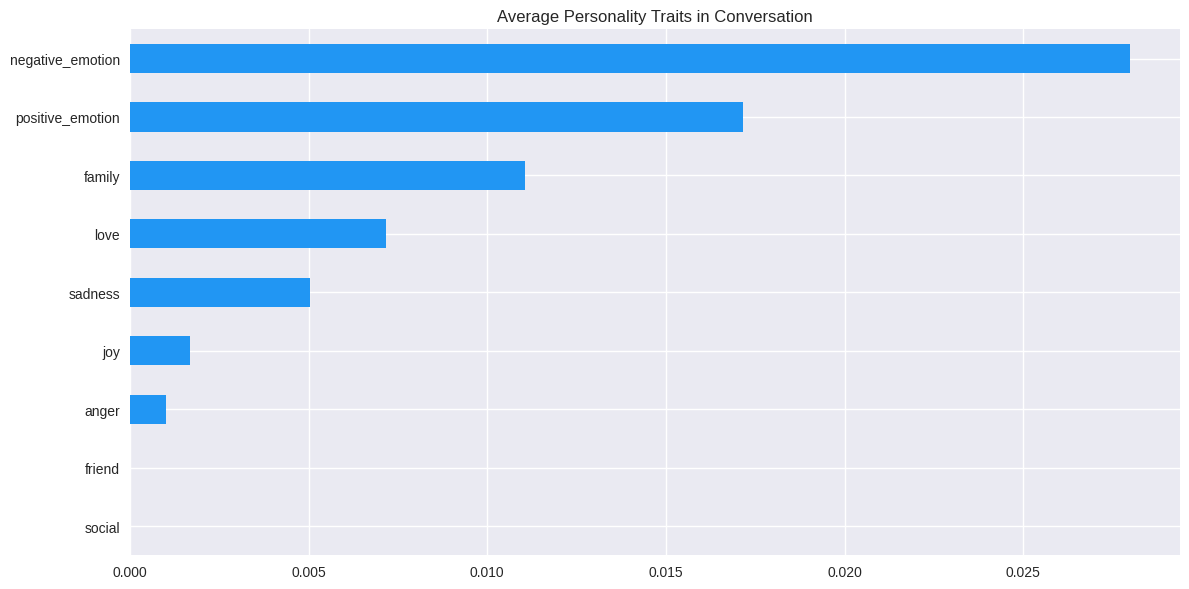

In [ ]:
# Perform personality analysis
print("Performing personality analysis...")
personality_df = analyze_personality_texts(chat_df['Cleaned_Text'].tolist())
chat_df = pd.concat([chat_df, personality_df], axis=1)

# Save personality data
chat_df.to_csv(PERSONALITY_CSV_OUTPUT, index=False)
print(f"Personality data saved to {PERSONALITY_CSV_OUTPUT}")

# Visualize personality traits
if not personality_df.empty:
    plt.figure(figsize=(12, 6))
    personality_df.mean().sort_values().plot(kind='barh', color=COLOR_PALETTE['highlight'])
    plt.title("Average Personality Traits in Conversation")
    plt.tight_layout()
    plt.show()

In [ ]:
# Perform topic modeling (on a sample if dataset is large)
print("Performing topic modeling...")
sample_texts = chat_df['Cleaned_Text'].sample(min(SAMPLE_SIZE, len(chat_df))).tolist()
topic_model, topics, topic_info = perform_topic_modeling(sample_texts)

if topic_model is not None:
    # Get top topics
    print("\nTop Topics Identified:")
    print(topic_info.head(NUM_TOPICS))

    # Visualize topics
    fig = topic_model.visualize_barchart(top_n_topics=NUM_TOPICS, n_words=TOP_N_WORDS)
    fig.show()

    # Assign topics to full dataset
    chat_df['Topic'] = -1  # Default for untrained samples
    if len(sample_texts) == len(chat_df):
        chat_df['Topic'] = topics

    # Save topic data
    chat_df.to_csv(TOPIC_CSV_OUTPUT, index=False)
    print(f"Topic data saved to {TOPIC_CSV_OUTPUT}")

2025-04-19 16:25:27,896 - BERTopic - Embedding - Transforming documents to embeddings.


Performing topic modeling...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Error in topic modeling: 'float' object is not subscriptable


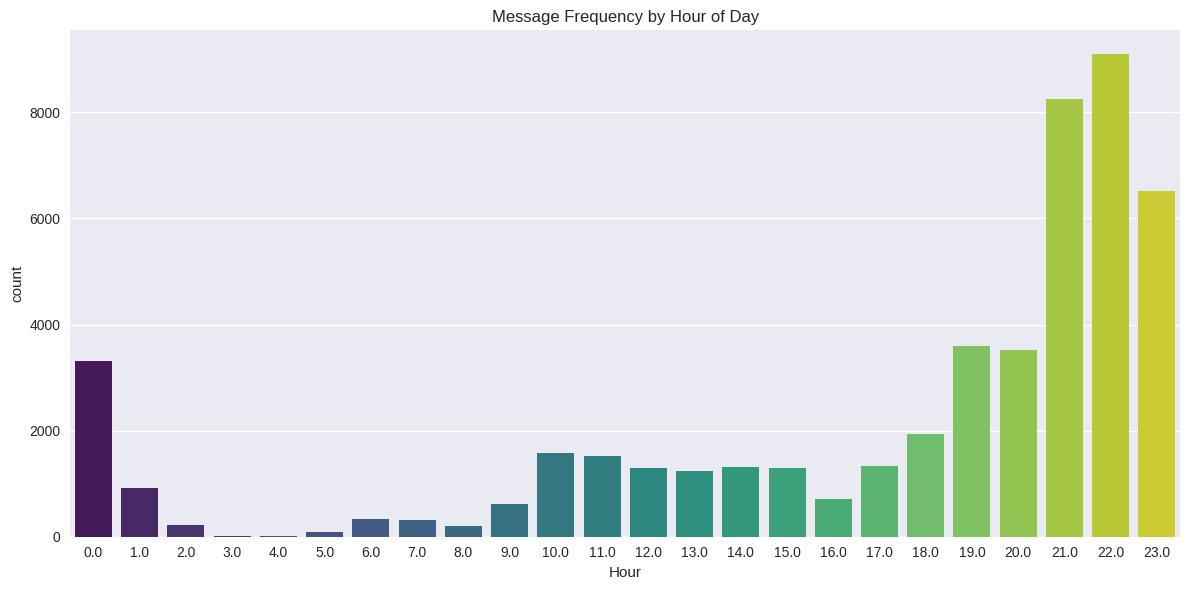

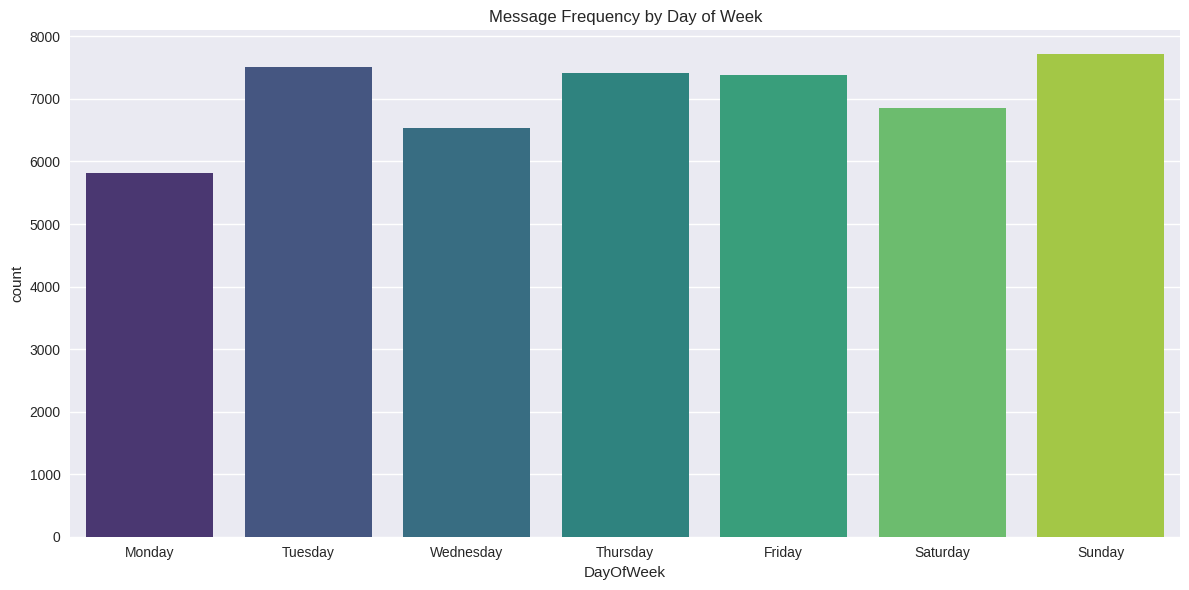

In [ ]:
# Temporal analysis - messages by hour
plt.figure(figsize=(12, 6))
sns.countplot(x='Hour', data=chat_df, palette='viridis')
plt.title("Message Frequency by Hour of Day")
plt.tight_layout()
plt.show()

# Temporal analysis - messages by day of week
plt.figure(figsize=(12, 6))
sns.countplot(x='DayOfWeek', data=chat_df,
             order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
             palette='viridis')
plt.title("Message Frequency by Day of Week")
plt.tight_layout()
plt.show()

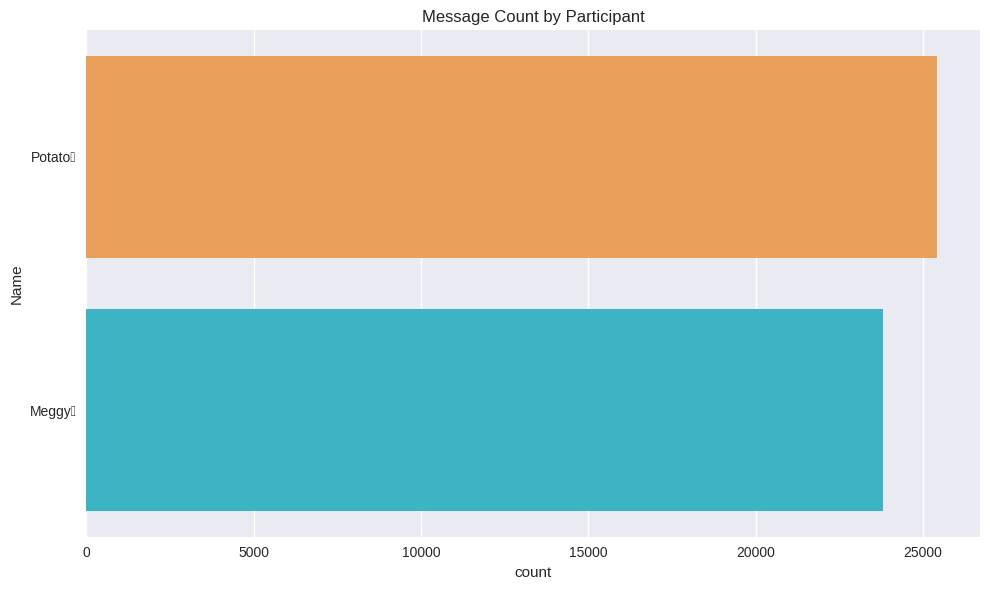

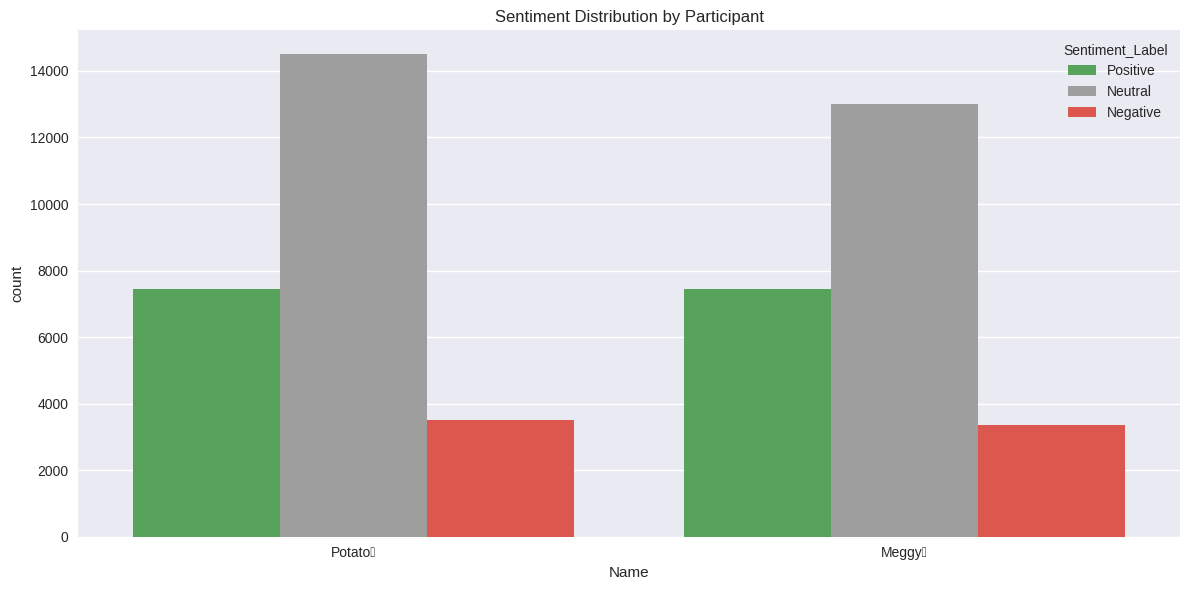

In [ ]:
# Participant analysis
if 'Name' in chat_df.columns:
    # Message count by participant
    plt.figure(figsize=(10, 6))
    sns.countplot(y='Name', data=chat_df,
                 order=chat_df['Name'].value_counts().index,
                 palette=[COLOR_PALETTE['person1'], COLOR_PALETTE['person2'], COLOR_PALETTE['system']])
    plt.title("Message Count by Participant")
    plt.tight_layout()
    plt.show()

    # Sentiment by participant
    if 'Sentiment_Label' in chat_df.columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(x='Name', hue='Sentiment_Label', data=chat_df,
                     hue_order=['Positive', 'Neutral', 'Negative'],
                     palette=[COLOR_PALETTE['positive'], COLOR_PALETTE['neutral'], COLOR_PALETTE['negative']])
        plt.title("Sentiment Distribution by Participant")
        plt.tight_layout()
        plt.show()

In [ ]:
# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"Total messages analyzed: {len(chat_df)}")
if 'Sentiment_Label' in chat_df.columns:
    print("\nSentiment Distribution:")
    print(chat_df['Sentiment_Label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

if 'Name' in chat_df.columns:
    print("\nParticipant Contribution:")
    print(chat_df['Name'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


=== Summary Statistics ===
Total messages analyzed: 54676

Sentiment Distribution:
Sentiment_Label
Neutral     55.8%
Positive    30.2%
Negative    14.0%
Name: proportion, dtype: object

Participant Contribution:
Name
Potato🩷    51.6%
Meggy🌼     48.4%
Name: proportion, dtype: object


In [ ]:
def analyze_user_engagement(df):
    """
    Analyze user engagement metrics including:
    - Media shared per user (counting <Media omitted> messages)
    - Emoji usage per user (excluding media messages)
    - Words per user (excluding media messages)

    Parameters:
        df (DataFrame): The WhatsApp chat DataFrame

    Returns:
        dict: A dictionary containing DataFrames with the analysis results
    """

    # Initialize results dictionary
    results = {}

    # Create a copy to avoid modifying the original dataframe
    df_analysis = df.copy()

    # 1. Media shared per user - count <Media omitted> or similar patterns
    media_pattern = re.compile(r'<Media.*?>', re.IGNORECASE)
    df_analysis['IsMedia'] = df_analysis['Text'].str.contains(media_pattern, na=False)

    if 'Name' in df_analysis.columns:
        media_counts = df_analysis[df_analysis['IsMedia']].groupby('Name').size().reset_index(name='Media_Count')
        media_percentage = df_analysis[df_analysis['IsMedia']]['Name'].value_counts(normalize=True).mul(100).round(1)
        results['media_analysis'] = {
            'counts': media_counts,
            'percentage': media_percentage
        }

    # 2. Emoji usage per user (excluding media messages)
    if 'Text' in df_analysis.columns and 'Name' in df_analysis.columns:
        # Count emojis per message per user
        emoji_pattern = re.compile(r':[a-z_]+:')

        def count_emojis(text):
            if not isinstance(text, str) or media_pattern.search(text):
                return 0
            return len(emoji_pattern.findall(emoji.demojize(text, delimiters=(" ", " "))))

        df_analysis['Emoji_Count'] = df_analysis['Text'].apply(count_emojis)
        emoji_counts = df_analysis.groupby('Name')['Emoji_Count'].agg(['sum', 'mean']).reset_index()
        emoji_counts.columns = ['Name', 'Total_Emojis', 'Avg_Emojis_Per_Message']
        results['emoji_analysis'] = emoji_counts

    # 3. Words per user (excluding media messages)
    if 'Text' in df_analysis.columns and 'Name' in df_analysis.columns:
        def count_words(text):
            if not isinstance(text, str) or media_pattern.search(text):
                return 0
            # Remove emojis and count words
            clean_text = emoji.demojize(text, delimiters=(" ", " "))
            words = re.sub(r'[^\w\s]', '', clean_text).split()
            return len(words)

        df_analysis['Word_Count'] = df_analysis['Text'].apply(count_words)
        word_stats = df_analysis.groupby('Name')['Word_Count'].agg(['sum', 'mean', 'median']).reset_index()
        word_stats.columns = ['Name', 'Total_Words', 'Avg_Words_Per_Message', 'Median_Words_Per_Message']
        results['word_analysis'] = word_stats

    return results

def plot_user_engagement(results):
    """
    Visualize the user engagement metrics

    Parameters:
        results (dict): The results dictionary from analyze_user_engagement()
    """
    if not results:
        print("No engagement data to visualize")
        return

    # 1. Plot media sharing
    if 'media_analysis' in results:
        plt.figure(figsize=(10, 5))
        if not results['media_analysis']['counts'].empty:
            sns.barplot(x='Name', y='Media_Count',
                        data=results['media_analysis']['counts'],
                        palette=[COLOR_PALETTE['person1'], COLOR_PALETTE['person2']])
            plt.title("Media Shared per User")
            plt.ylabel("Number of Media Files")

            # Add percentage annotations if available
            if not results['media_analysis']['percentage'].empty:
                for i, (name, pct) in enumerate(results['media_analysis']['percentage'].items()):
                    plt.text(i, results['media_analysis']['counts'].iloc[i]['Media_Count'] + 0.5,
                            f"{pct}%", ha='center')

            plt.tight_layout()
            plt.show()
        else:
            print("No media sharing data available")

    # 2. Plot emoji usage
    if 'emoji_analysis' in results and not results['emoji_analysis'].empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Total emojis
        sns.barplot(x='Name', y='Total_Emojis',
                   data=results['emoji_analysis'],
                   palette=[COLOR_PALETTE['person1'], COLOR_PALETTE['person2']],
                   ax=ax1)
        ax1.set_title("Total Emojis Used")
        ax1.set_ylabel("Count")

        # Average emojis per message
        sns.barplot(x='Name', y='Avg_Emojis_Per_Message',
                   data=results['emoji_analysis'],
                   palette=[COLOR_PALETTE['person1'], COLOR_PALETTE['person2']],
                   ax=ax2)
        ax2.set_title("Average Emojis per Message")
        ax2.set_ylabel("Count")

        plt.tight_layout()
        plt.show()

    # 3. Plot word usage
    if 'word_analysis' in results and not results['word_analysis'].empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        metrics = ['Total_Words', 'Avg_Words_Per_Message', 'Median_Words_Per_Message']
        titles = ["Total Words", "Average Words per Message", "Median Words per Message"]

        for ax, metric, title in zip(axes, metrics, titles):
            sns.barplot(x='Name', y=metric,
                       data=results['word_analysis'],
                       palette=[COLOR_PALETTE['person1'], COLOR_PALETTE['person2']],
                       ax=ax)
            ax.set_title(title)
            ax.set_ylabel("Count" if metric == 'Total_Words' else "Words")

        plt.tight_layout()
        plt.show()


Media shared per user:
Empty DataFrame
Columns: [Name, Media_Count]
Index: []

Percentage of media shared:
Series([], Name: proportion, dtype: float64)

Emoji usage:
      Name  Total_Emojis  Avg_Emojis_Per_Message
0   Meggy🌼             0                     0.0
1  Potato🩷             0                     0.0

Word usage:
      Name  Total_Words  Avg_Words_Per_Message  Median_Words_Per_Message
0   Meggy🌼       145271               6.102541                       5.0
1  Potato🩷       138547               5.448386                       4.0
No media sharing data available


<Figure size 1000x500 with 0 Axes>

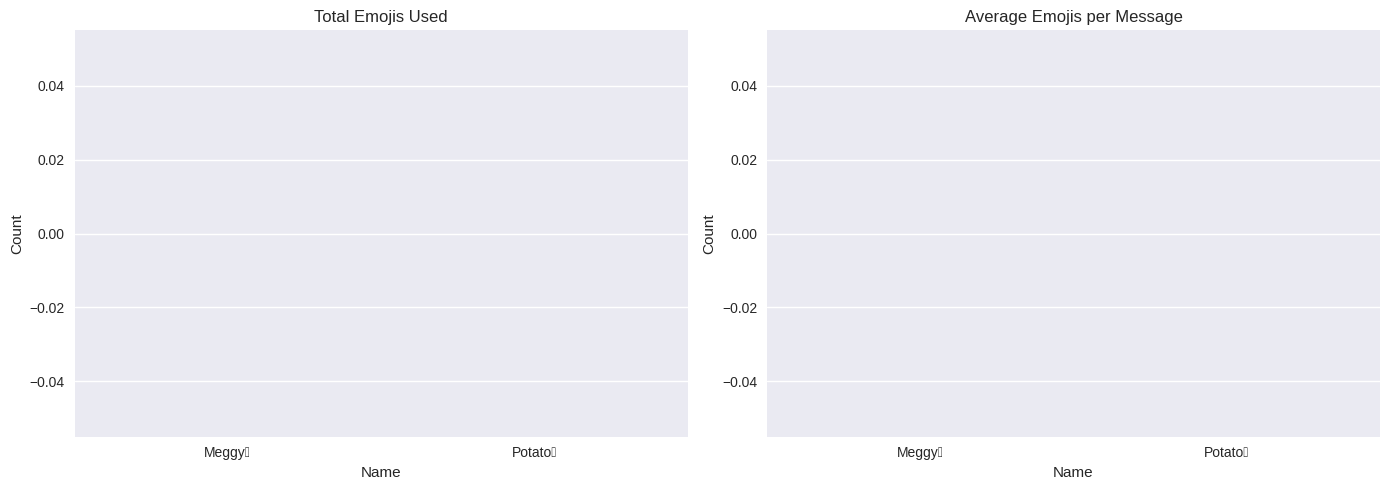

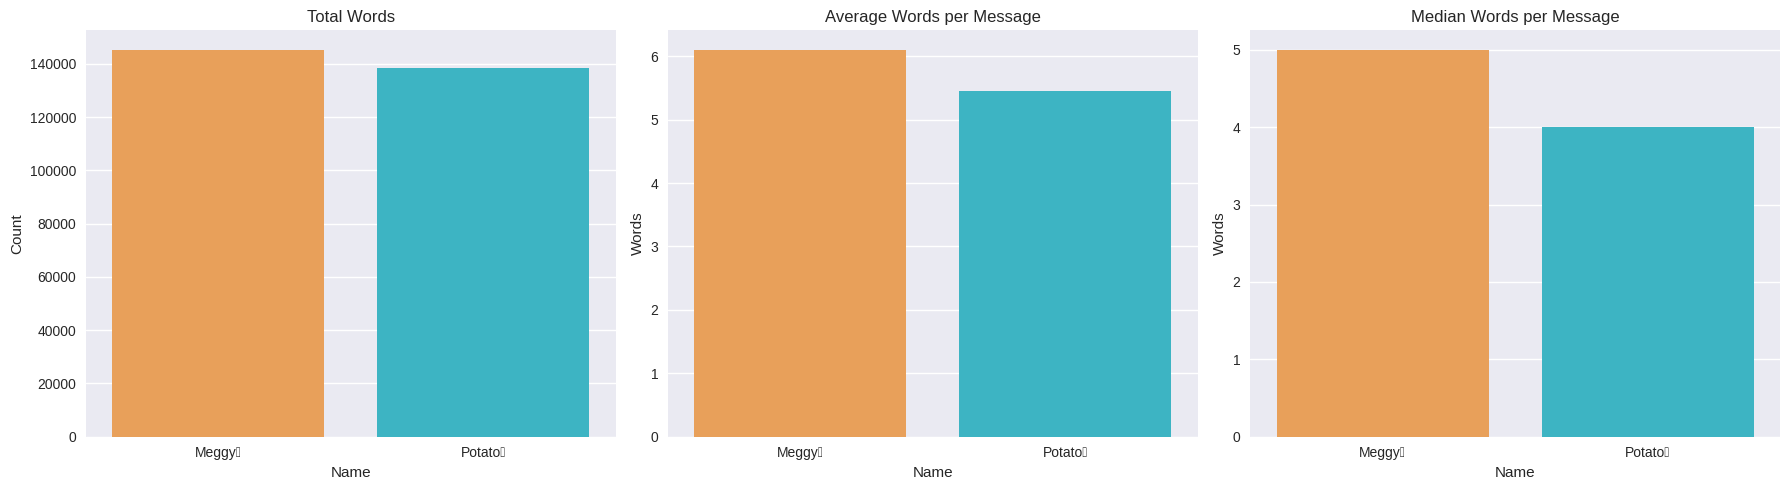

In [ ]:
# Run the analysis
engagement_results = analyze_user_engagement(chat_df)

# Display numerical results
print("\nMedia shared per user:")
print(engagement_results['media_analysis']['counts'])
print("\nPercentage of media shared:")
print(engagement_results['media_analysis']['percentage'])

print("\nEmoji usage:")
print(engagement_results['emoji_analysis'])

print("\nWord usage:")
print(engagement_results['word_analysis'])

# Visualize the results
plot_user_engagement(engagement_results)